
# 03b — Spatial MSP/LCA visualization using the legacy Figure-5 scheme

This notebook is **visualization only**. It does not rerun Brightway, TEA, or sLCC.

It reproduces the old `spatial_elefeed_LCI_localv11_yrdmg.ipynb` main spatial visualization scheme:

- top row: BC2 and BO2 MSP difference versus market synthetic graphite;
- top-right: the six coarse U.S. study regions and a separate region legend;
- second row: four BC2 environmental-impact differences versus market;
- third row: the same four BO2 environmental-impact differences;
- diverging `RdBu_r` maps centered at zero, with black state borders;
- market benchmark annotation in each quantitative panel;
- category-level **dynamic unit scaling** (e.g. kg → g → mg) applied consistently to both state deltas and market annotations.

All quantitative values come from the **current cleaned spatial workflow outputs**:
`result/spatial/state_tea.csv` and `result/spatial/state_lca.csv`.
Market values are obtained through the current centralized market-reference utilities and `graphite_impacts_long.csv`.

Run `03_spatial_lca_tea_slcc_with_ALL.ipynb` first whenever the spatial calculations are updated.


It also generates **supporting-information (SI)** maps for every canonical current LCIA category not shown in the four-category main figure, using the same market comparison, compact-U.S. geometry, diverging color treatment, and dynamic unit logic.


### Expanded SI coverage

The SI section now covers **all four biographite pathways (BC1, BC2, BO1, BO2)** and both
market reference types (**synthetic graphite and natural graphite**).

The main-text legacy figure remains BC2/BO2 versus market synthetic graphite. SI outputs add:

- BC2/BO2 versus market natural graphite in the same legacy 3×4 layout;
- BC1/BO1 versus market synthetic graphite in the same legacy 3×4 layout;
- BC1/BO1 versus market natural graphite in the same legacy 3×4 layout;
- the remaining LCIA categories (currently freshwater ecotoxicity and smog) in separate
  BC1/BO1 and BC2/BO2 2×2 legacy-style figures versus synthetic graphite;
- the same pairwise SI figures versus natural graphite;
- state-level and coarse-region tables covering all four pathways, both market benchmarks, MSP,
  and all six canonical LCIA categories.

All market comparisons use the same `build_lca_delta_table()` / `market_impact_means()` logic used
by the current `03_spatial_lca_tea_slcc_with_ALL.ipynb`.


In [75]:

from pathlib import Path
import sys
import math

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
from matplotlib.ticker import FuncFormatter
import matplotlib.transforms as mtransforms
from shapely import affinity as sa
from shapely.ops import unary_union

# ---------------------------------------------------------------------
# Locate project root
# ---------------------------------------------------------------------
HERE = Path.cwd().resolve()
_candidates = [HERE, HERE.parent, HERE.parent.parent, HERE.parent.parent.parent]
PROJECT_ROOT = next((p for p in _candidates if (p / "graphite_sus").is_dir()), None)

if PROJECT_ROOT is None:
    raise RuntimeError(
        "Could not locate project root containing graphite_sus/.\n"
        f"Current directory: {HERE}"
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from graphite_sus.spatial.config import SpatialPaths, CANON_IMPACTS
from graphite_sus.plots.spatial_lca_maps import build_lca_delta_table
from graphite_sus.market_reference import get_market_mean, get_market_range
from graphite_sus.scenarios import SC_LABEL

PATHS = SpatialPaths()
OUTPUT_DIR = PROJECT_ROOT / "result" / "spatial"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Spatial results:", OUTPUT_DIR)


Project root: /mnt/g/My Drive/yale/Project-graphite/graphite_clean_project_spatial_v2_with_03b_legacy_visualization/graphite_clean_project_spatial_v2
Spatial results: /mnt/g/My Drive/yale/Project-graphite/graphite_clean_project_spatial_v2_with_03b_legacy_visualization/graphite_clean_project_spatial_v2/result/spatial


## 1. Visualization settings

In [76]:

# Main-text comparison settings
SCENARIO_TOP = "s_c2"       # BC2
SCENARIO_BOTTOM = "s_o2"    # BO2
MARKET_KIND = "synthetic"
PRICE_STAT = "mean"

SCENARIO_PAIRS = {
    "BC2_BO2": ("s_c2", "s_o2"),
    "BC1_BO1": ("s_c1", "s_o1"),
}
ALL_SCENARIOS = ("s_c1", "s_c2", "s_o1", "s_o2")
MARKET_KINDS = ("synthetic", "natural")

# Same four environmental categories used in the old 3×4 figure.
ENV_CATEGORIES = [
    "climate change",
    "eutrophication",
    "particulate matter formation",
    "acidification",
]

# Old figure styling
DELTA_CMAP = "RdBu_r"
REGION_COLORS = [
    "#e4237b",
    "#6169ab",
    "#1c8474",
    "#a1becb",
    "#e38cb1",
    "#294e5e",
]
REGION_CMAP = ListedColormap(REGION_COLORS, name="legacy_region_cmap")

FIGSIZE_PER_PLOT = (4.5, 4.2)
TITLE_FS = 16
PANEL_LABEL_FS = 16
MARKET_TEXT_FS = 16
REGION_LABEL_FS = 16

# The old notebook had an extra "flat legend" unit bump for quantile-class maps.
# This 3×4 delta figure uses continuous colorbars, so False gives clearer units
# (e.g. climate in kg, acidification/eutrophication/PM in g). Set True only if
# you want the old helper's additional kg→g→mg bump exactly.
LEGACY_FLAT_UNIT_BUMP = False

SAVE_PNG = True
SAVE_PDF = True

print("Market synthetic MSP mean:", get_market_mean(MARKET_KIND), "USD/kg")
print("Market synthetic MSP range:", get_market_range(MARKET_KIND), "USD/kg")


Market synthetic MSP mean: 4.75 USD/kg
Market synthetic MSP range: (4.2, 5.3) USD/kg


## 2. Load the current spatial outputs and geometry

In [77]:

STATE_TEA_PATH = OUTPUT_DIR / "state_tea.csv"
STATE_LCA_PATH = OUTPUT_DIR / "state_lca.csv"

required = [STATE_TEA_PATH, STATE_LCA_PATH, PATHS.market_impacts, PATHS.state_geometries]
missing = [str(p) for p in required if not Path(p).exists()]
if missing:
    raise FileNotFoundError(
        "Required current spatial outputs/inputs are missing:\n- "
        + "\n- ".join(missing)
        + "\nRun 03_spatial_lca_tea_slcc_with_ALL.ipynb first."
    )

state_tea = pd.read_csv(STATE_TEA_PATH)
state_lca = pd.read_csv(STATE_LCA_PATH)
market_df = pd.read_csv(PATHS.market_impacts)

states = gpd.read_file(PATHS.state_geometries)

# Prefer a postal-abbreviation field. In the bundled GeoJSON, ``state`` is a
# numeric FIPS code, while ``stusab`` is the two-letter state abbreviation.
state_col = next(
    c for c in ["stusab", "STUSPS", "stusps", "postal", "abbr", "state"]
    if c in states.columns
)
states = states[[state_col, "geometry"]].rename(columns={state_col: "state"}).copy()
states["state"] = states["state"].astype(str).str.upper()
states = states.loc[
    states["state"].isin(
        set(state_tea["state"].astype(str).str.upper())
    )
].copy()

# Hard checks: current result tables should have one row/state/scenario.
assert state_tea["state"].nunique() >= 48
assert state_lca["state"].nunique() >= 48
assert set(ENV_CATEGORIES).issubset(state_lca.columns)
assert not state_tea.duplicated(["state", "scenario"]).any()
assert not state_lca.duplicated(["state", "scenario"]).any()

display(
    state_tea.groupby("scenario")["MSP"].agg(["min", "mean", "max"]).round(4)
)
display(
    state_lca.groupby("scenario")[ENV_CATEGORIES].agg(["min", "mean", "max"])
)


,min,mean,max
scenario,,,
s_c1,4.0486,4.3440,5.5749
s_c2,4.1152,4.4290,5.7653
s_o1,5.5692,5.9663,7.0853
s_o2,4.8322,5.2279,6.3343


climate change                     eutrophication            \
                    min      mean       max            min      mean   
scenario                                                               
s_c1           3.824511  5.083586  7.523922       0.012619  0.024512   
s_c2           4.040685  5.077465  7.041655       0.009434  0.018961   
s_o1           5.267440  6.423220  8.610698       0.015836  0.026436   
s_o2           2.848850  3.480639  4.678437       0.008766  0.014572   

                   particulate matter formation                      \
               max                          min      mean       max   
scenario                                                              
s_c1      0.040593                     0.002885  0.007157  0.014408   
s_c2      0.031844                     0.002172  0.005596  0.011414   
s_o1      0.040770                     0.003101  0.006911  0.013385   
s_o2      0.022424                     0.001715  0.003802  0.007348   

         acidification                      
                   min      mean       max  
scenario                                    
s_c1          0.013979  0.019011  0.044467  
s_c2          0.011849  0.015993  0.036251  
s_o1          0.016749  0.021372  0.043895  
s_o2          0.009216  0.011744  0.024087


## 3. Coarse U.S. study-region definition

This is the same six-region state assignment used in the old notebook. It is now stored explicitly in
`graphite_sus/data/spatial/study_region_definition.csv` so the figure no longer depends on an inline, hidden mapping.
This region definition is for **summary/visualization** and is distinct from the electricity-region, natural-gas-basin,
and PADD assignments used to calculate the spatial LCA.


In [78]:

REGION_PATH = PROJECT_ROOT / "graphite_sus" / "data" / "spatial" / "study_region_definition.csv"
region_def = pd.read_csv(REGION_PATH)
region_def["state"] = region_def["state"].astype(str).str.upper()

REGION_ORDER = [
    "Pacific",
    "Western+Texas",
    "Central",
    "Upper",
    "Eastern",
    "Northeast coastal",
]

assert region_def["state"].nunique() == 51
assert set(region_def["region"]) == set(REGION_ORDER)

display(
    region_def.groupby("region", sort=False)["state"]
    .apply(lambda s: ", ".join(sorted(s)))
    .reindex(REGION_ORDER)
    .to_frame("states")
)


,states
region,
Pacific,"AK, CA, HI"
Western+Texas,"AZ, CO, ID, MT, NM, NV, OR, TX, UT, WA, WY"
Central,"KS, NE, OK"
Upper,"IA, MN, ND, SD, WI"
Eastern,"AL, AR, DC, DE, FL, GA, IL, IN, KY, LA, MD, MI..."
Northeast coastal,"CT, MA, ME, NH, RI, VT"


## 4. Compact-U.S. layout and dynamic unit helpers

In [79]:

# ---------------------------------------------------------------------
# Compact geometry: reproduced from the old visualization notebook
# ---------------------------------------------------------------------
def _state_col(df):
    for c in df.columns:
        if str(c).lower() in ("state", "state_name", "name", "stusps"):
            return c
    raise KeyError("No state-name column found.")

def _scale_about_center(geom, fx, fy=None):
    fy = fx if fy is None else fy
    cx, cy = geom.centroid.coords[0]
    return sa.scale(geom, xfact=fx, yfact=fy, origin=(cx, cy))

def _rotate_about_center(geom, angle_deg):
    cx, cy = geom.centroid.coords[0]
    return sa.rotate(geom, angle_deg, origin=(cx, cy))

def _move_to_center(geom, x, y):
    cx, cy = geom.centroid.coords[0]
    return sa.translate(geom, xoff=x - cx, yoff=y - cy)

def compact_us_geometries(
    gdf_in,
    *,
    crs="EPSG:5070",
    ak_scale=0.36,
    ak_rotate=-32,
    hi_scale=1.15,
    pr_scale=1.0,
):
    gdf = gdf_in.copy()
    if gdf.crs is None:
        gdf = gdf.set_crs("EPSG:4326")
    if gdf.crs.is_geographic:
        gdf = gdf.to_crs(crs)

    scol = _state_col(gdf)
    vals = gdf[scol].astype(str).str.upper()

    AK = {"AK", "ALASKA"}
    HI = {"HI", "HAWAII"}
    PR = {"PR", "PUERTO RICO", "P.R."}
    NON_CONTIG = AK | HI | PR

    contig = (
        gdf.loc[~vals.isin(NON_CONTIG), [scol, "geometry"]]
        .drop_duplicates(subset=[scol])
    )
    minx, miny, maxx, maxy = contig.total_bounds
    W, H = maxx - minx, maxy - miny

    targets = {}

    if vals.isin(AK).any():
        ak = unary_union(gdf.loc[vals.isin(AK), "geometry"])
        ak = _rotate_about_center(ak, ak_rotate)
        ak = _scale_about_center(ak, ak_scale)
        ak = _move_to_center(ak, minx + 0.17 * W, miny - 0.14 * H)
        targets["AK"] = ak
        targets["ALASKA"] = ak

    if vals.isin(HI).any():
        hi = unary_union(gdf.loc[vals.isin(HI), "geometry"])
        hi = _scale_about_center(hi, hi_scale)
        hi = _move_to_center(hi, minx + 0.32 * W, miny - 0.15 * H)
        targets["HI"] = hi
        targets["HAWAII"] = hi

    if vals.isin(PR).any():
        pr = unary_union(gdf.loc[vals.isin(PR), "geometry"])
        pr = _scale_about_center(pr, pr_scale)
        pr = _move_to_center(pr, minx + 0.74 * W, miny - 0.08 * H)
        targets["PR"] = pr
        targets["PUERTO RICO"] = pr
        targets["P.R."] = pr

    for key, geom in targets.items():
        gdf.loc[gdf[scol].astype(str).str.upper().eq(key), "geometry"] = geom

    return gdf


def _panel_label_transform(ax, dx_pts=-12, dy_pts=0):
    return ax.transAxes + mtransforms.ScaledTranslation(
        dx_pts / 72.0,
        dy_pts / 72.0,
        ax.figure.dpi_scale_trans,
    )


# ---------------------------------------------------------------------
# Dynamic unit scaling
# ---------------------------------------------------------------------
# Base units correspond to the LCIA methods used by the current 03 notebook.
BASE_UNITS = {
    "MSP": "USD",
    "climate change": "kg CO$_2$-eq",
    "acidification": "kg SO$_2$-eq",
    "eutrophication": "kg N-eq",
    "ecotoxicity: freshwater": "CTUe",
    "particulate matter formation": "kg PM$_{2.5}$-eq",
    "photochemical oxidant formation": "kg O$_3$-eq",
}

PRETTY_NAMES = {
    "MSP": "MSP",
    "climate change": "Climate change",
    "acidification": "Acidification",
    "eutrophication": "Eutrophication",
    "ecotoxicity: freshwater": "Freshwater ecotoxicity",
    "particulate matter formation": "Respiratory effects",
    "photochemical oxidant formation": "Smog",
}

def _replace_mass_prefix(unit, prefix):
    # All mass-based units begin with "kg " in BASE_UNITS.
    if not unit.startswith("kg "):
        return unit
    return prefix + unit[2:]


def _quantile_labels_flat(values, decimals=2):
    a = pd.to_numeric(pd.Series(values), errors="coerce").dropna().to_numpy(float)
    if a.size < 2:
        return False
    qs = np.quantile(a, np.linspace(0.2, 1.0, 5))
    return len({round(float(x), decimals) for x in qs}) <= 3


def choose_dynamic_scale(values, base_unit):
    """
    Return (multiplier, display_unit).

    This follows the old notebook's magnitude logic:
      kg values < 0.5 -> g
      kg values < 1e-3 -> mg

    It also retains the old 'flat legend' idea, but uses explicit mass prefixes
    rather than ambiguous labels such as 'mg ×10^3'.
    """
    a = pd.to_numeric(pd.Series(values), errors="coerce").dropna().to_numpy(float)
    max_abs = float(np.max(np.abs(a))) if a.size else 0.0

    # Non-mass metrics (MSP, CTUe) are not rescaled.
    if not base_unit.startswith("kg "):
        return 1.0, base_unit

    prefixes = [
        ("kg", 1.0),
        ("g", 1e3),
        ("mg", 1e6),
        ("µg", 1e9),
    ]

    if max_abs < 1e-3:
        idx = 2  # mg
    elif max_abs < 0.5:
        idx = 1  # g
    else:
        idx = 0  # kg

    scaled = a * prefixes[idx][1] if a.size else a

    # Optional old-notebook extra bump. It was useful for discrete quantile
    # legends, but is normally unnecessary for the continuous colorbars here.
    if LEGACY_FLAT_UNIT_BUMP and idx < len(prefixes) - 1 and _quantile_labels_flat(scaled):
        idx += 1

    prefix, multiplier = prefixes[idx]
    return multiplier, _replace_mass_prefix(base_unit, prefix)


def legend_fmt_for_values(values, small_decimals=2, large_decimals=1):
    a = pd.to_numeric(pd.Series(values), errors="coerce").dropna().to_numpy(float)
    if a.size == 0:
        return f"{{:.{small_decimals}f}}"
    max_abs = float(np.max(np.abs(a)))
    if max_abs == 0:
        return f"{{:.{small_decimals}f}}"
    integer_digits = 1 if max_abs < 1 else int(math.floor(math.log10(max_abs))) + 1
    decimals = large_decimals if integer_digits + small_decimals >= 4 else small_decimals
    return f"{{:.{decimals}f}}"


## 5. Build the new-data delta table

In [80]:

delta_tables = {
    market_kind: build_lca_delta_table(
        state_tea=state_tea,
        state_lca=state_lca,
        market_df=market_df,
        market_kind=market_kind,
        price_stat=PRICE_STAT,
    )
    for market_kind in MARKET_KINDS
}

# Main-text Figure 5 stays tied to the synthetic-graphite benchmark.
delta_table = delta_tables[MARKET_KIND]

needed_metrics = ["MSP", *ENV_CATEGORIES]
delta_plot = delta_table.loc[
    delta_table["scenario"].isin([SCENARIO_TOP, SCENARIO_BOTTOM])
    & delta_table["metric"].isin(needed_metrics)
].copy()

# Hard checks for both benchmarks.
for market_kind, d in delta_tables.items():
    assert not d.duplicated(["state", "scenario", "metric"]).any()
    assert set(ALL_SCENARIOS).issubset(set(d["scenario"].unique()))
    assert set(["MSP", *CANON_IMPACTS]).issubset(set(d["metric"].unique()))
    assert set(d["market_type"].dropna().unique()) == {market_kind}

display(
    delta_plot.groupby(["scenario", "metric"])[["green_value", "benchmark", "delta"]]
    .agg(["min", "mean", "max"])
)

display(
    pd.DataFrame(
        {
            kind: {
                "MSP_mean_USD_per_kg": get_market_mean(kind),
                "MSP_low_USD_per_kg": get_market_range(kind)[0],
                "MSP_high_USD_per_kg": get_market_range(kind)[1],
            }
            for kind in MARKET_KINDS
        }
    ).T
)


green_value                      \
                                              min      mean       max   
scenario metric                                                         
s_c2     MSP                             4.115199  4.429029  5.765265   
         acidification                   0.011849  0.015993  0.036251   
         climate change                  4.040685  5.077465  7.041655   
         eutrophication                  0.009434  0.018961  0.031844   
         particulate matter formation    0.002172  0.005596  0.011414   
s_o2     MSP                             4.832228  5.227914  6.334275   
         acidification                   0.009216  0.011744  0.024087   
         climate change                  2.848850  3.480639  4.678437   
         eutrophication                  0.008766  0.014572  0.022424   
         particulate matter formation    0.001715  0.003802  0.007348   

                                      benchmark                         delta  \
                                            min      mean       max       min   
scenario metric                                                                 
s_c2     MSP                           4.750000  4.750000  4.750000 -0.634801   
         acidification                 0.057040  0.057040  0.057040 -0.045191   
         climate change                4.869185  4.869185  4.869185 -0.828500   
         eutrophication                0.014235  0.014235  0.014235 -0.004801   
         particulate matter formation  0.008957  0.008957  0.008957 -0.006785   
s_o2     MSP                           4.750000  4.750000  4.750000  0.082228   
         acidification                 0.057040  0.057040  0.057040 -0.047824   
         climate change                4.869185  4.869185  4.869185 -2.020335   
         eutrophication                0.014235  0.014235  0.014235 -0.005469   
         particulate matter formation  0.008957  0.008957  0.008957 -0.007242   

                                                           
                                           mean       max  
scenario metric                                            
s_c2     MSP                          -0.320971  1.015265  
         acidification                -0.041047 -0.020789  
         climate change                0.208280  2.172470  
         eutrophication                0.004726  0.017609  
         particulate matter formation -0.003361  0.002457  
s_o2     MSP                           0.477914  1.584275  
         acidification                -0.045296 -0.032953  
         climate change               -1.388546 -0.190748  
         eutrophication                0.000337  0.008189  
         particulate matter formation -0.005155 -0.001609

,MSP_mean_USD_per_kg,MSP_low_USD_per_kg,MSP_high_USD_per_kg
synthetic,4.75,4.2,5.3
natural,3.65,2.8,4.5


## 6. Legacy 3×4 figure function, current data

In [81]:

def plot_current_spatial_legacy_scheme(
    states_gdf,
    delta_df,
    region_def,
    *,
    scenario_top=SCENARIO_TOP,
    scenario_bottom=SCENARIO_BOTTOM,
    env_categories=ENV_CATEGORIES,
    delta_cmap=DELTA_CMAP,
    region_cmap=REGION_CMAP,
    figsize_per_plot=FIGSIZE_PER_PLOT,
    title_fs=TITLE_FS,
    panel_label_fs=PANEL_LABEL_FS,
    market_text_fs=MARKET_TEXT_FS,
    region_label_states=("TX",),
    region_label_fs=REGION_LABEL_FS,
    market_kind=MARKET_KIND,
):
    """
    Reproduce the old 3×4 Figure-5 layout using the current cleaned data.

    Row 1:
      (a) BC2 ΔMSP
      (b) BO2 ΔMSP
      (c) six-region map
      legend-only axis

    Row 2:
      (d–g) BC2 environmental deltas

    Row 3:
      (h–k) BO2 environmental deltas
    """
    env_categories = list(env_categories)
    if len(env_categories) != 4:
        raise ValueError("env_categories must contain exactly four categories.")

    metrics = ["MSP", *env_categories]
    scenarios = [scenario_top, scenario_bottom]

    # Geometry once, then reuse the same compact layout in every panel.
    g_states = states_gdf[["state", "geometry"]].drop_duplicates("state").copy()
    g_states["state"] = g_states["state"].astype(str).str.upper()
    g_states = compact_us_geometries(g_states)

    # Category-wide scaling is shared by BC2 and BO2 and includes the market
    # benchmark, exactly as in the old plotting function.
    scale_meta = {}
    scaled = delta_df.copy()

    for metric in metrics:
        d = scaled.loc[scaled["metric"].eq(metric)]
        values_for_scale = np.r_[
            pd.to_numeric(d["delta"], errors="coerce").to_numpy(float),
            pd.to_numeric(d["benchmark"], errors="coerce").to_numpy(float),
        ]
        base_unit = BASE_UNITS[metric]
        multiplier, unit = choose_dynamic_scale(values_for_scale, base_unit)
        scale_meta[metric] = {"multiplier": multiplier, "unit": unit}

        mask = scaled["metric"].eq(metric)
        scaled.loc[mask, "delta_scaled"] = (
            pd.to_numeric(scaled.loc[mask, "delta"], errors="coerce") * multiplier
        )
        scaled.loc[mask, "benchmark_scaled"] = (
            pd.to_numeric(scaled.loc[mask, "benchmark"], errors="coerce") * multiplier
        )

    # Symmetric color range per metric, shared across BC2/BO2.
    vmax_by_metric = {}
    for metric in metrics:
        vals = pd.to_numeric(
            scaled.loc[scaled["metric"].eq(metric), "delta_scaled"],
            errors="coerce",
        ).dropna()
        vmax = float(vals.abs().max()) if len(vals) else 1.0
        vmax_by_metric[metric] = vmax if vmax > 0 else 1.0

    fig_w = figsize_per_plot[0] * 4
    fig_h = figsize_per_plot[1] * 3
    fig, axes = plt.subplots(
        3,
        4,
        figsize=(fig_w, fig_h),
        subplot_kw={"aspect": "equal"},
        constrained_layout=True,
    )

    panel_label_map = {
        (0, 0): "(a)",
        (0, 1): "(b)",
        (0, 2): "(c)",
        (1, 0): "(d)",
        (1, 1): "(e)",
        (1, 2): "(f)",
        (1, 3): "(g)",
        (2, 0): "(h)",
        (2, 1): "(i)",
        (2, 2): "(j)",
        (2, 3): "(k)",
    }

    pos_top = {
        "MSP": (0, 0),
        env_categories[0]: (1, 0),
        env_categories[1]: (1, 1),
        env_categories[2]: (1, 2),
        env_categories[3]: (1, 3),
    }
    pos_bottom = {
        "MSP": (0, 1),
        env_categories[0]: (2, 0),
        env_categories[1]: (2, 1),
        env_categories[2]: (2, 2),
        env_categories[3]: (2, 3),
    }

    market_kind = str(market_kind).strip().lower()
    if market_kind not in {"synthetic", "natural"}:
        raise ValueError("market_kind must be synthetic or natural")
    observed_markets = set(scaled["market_type"].dropna().astype(str).str.lower().unique())
    if observed_markets and observed_markets != {market_kind}:
        raise ValueError(
            f"delta_df market_type={sorted(observed_markets)} does not match market_kind={market_kind!r}"
        )
    market_label = f"market {market_kind}"

    def draw_delta_panel(ax, scenario, metric, panel_xy):
        d = scaled.loc[
            scaled["scenario"].eq(scenario) & scaled["metric"].eq(metric),
            ["state", "delta_scaled", "benchmark_scaled"],
        ].copy()
        m = g_states.merge(d, on="state", how="left", validate="one_to_one")

        vmax = vmax_by_metric[metric]
        norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
        vals = pd.to_numeric(m["delta_scaled"], errors="coerce")
        fmt_str = legend_fmt_for_values(vals, small_decimals=1)
        formatter = FuncFormatter(lambda x, pos, f=fmt_str: f.format(x))

        m.plot(
            column="delta_scaled",
            ax=ax,
            cmap=delta_cmap,
            edgecolor="black",
            linewidth=0.3,
            legend=False,
            norm=norm,
            missing_kwds={"color": "lightgrey"},
        )

        sm = cm.ScalarMappable(norm=norm, cmap=delta_cmap)
        sm.set_array(vals.to_numpy(float))
        cb = fig.colorbar(
            sm,
            ax=ax,
            fraction=0.035,
            pad=0.02,
            format=formatter,
        )
        cb.ax.tick_params(labelsize=14)

        gxmin, gymin, gxmax, gymax = g_states.total_bounds
        px = 0.02 * (gxmax - gxmin)
        py = 0.03 * (gymax - gymin)
        ax.set_xlim(gxmin - px, gxmax + px)
        ax.set_ylim(gymin - py, gymax + py)
        ax.set_axis_off()

        unit = scale_meta[metric]["unit"]
        pretty = PRETTY_NAMES[metric]
        sc_short = SC_LABEL.get(scenario, scenario)

        ax.set_title(
            f"{sc_short} – {market_label}\nΔ{pretty} ({unit})",
            fontsize=title_fs,
        )

        benchmark = pd.to_numeric(d["benchmark_scaled"], errors="coerce").dropna()
        if len(benchmark):
            market_value = float(benchmark.iloc[0])
            ax.text(
                0.98,
                0.05,
                f"Market: {market_value:.2f} {unit}",
                transform=ax.transAxes,
                ha="right",
                va="bottom",
                fontsize=market_text_fs,
                bbox=dict(
                    boxstyle="round,pad=0.2",
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.7,
                ),
            )

        label = panel_label_map[panel_xy]
        ax.text(
            0.0005,
            0.98,
            label,
            transform=_panel_label_transform(ax),
            ha="left",
            va="top",
            fontsize=panel_label_fs,
            fontweight="bold",
            clip_on=False,
        )

    for metric, rc in pos_top.items():
        draw_delta_panel(axes[rc], scenario_top, metric, rc)

    for metric, rc in pos_bottom.items():
        draw_delta_panel(axes[rc], scenario_bottom, metric, rc)

    # -------------------- region map --------------------
    ax_region = axes[0, 2]
    g_region = g_states.merge(region_def[["state", "region"]], on="state", how="left")
    g_region = g_region.dropna(subset=["region"]).copy()
    g_region["region"] = pd.Categorical(
        g_region["region"],
        categories=REGION_ORDER,
        ordered=True,
    )
    region_to_code = {r: i for i, r in enumerate(REGION_ORDER)}
    g_region["region_code"] = g_region["region"].map(region_to_code).astype(float)

    g_region.plot(
        column="region_code",
        ax=ax_region,
        legend=False,
        categorical=True,
        edgecolor="black",
        linewidth=0.3,
        cmap=region_cmap,
    )

    if region_label_states:
        labels = {str(s).upper() for s in region_label_states}
        g_lab = g_region.loc[g_region["state"].isin(labels)].copy()
        for (_, row), pt in zip(g_lab.iterrows(), g_lab.representative_point()):
            ax_region.text(
                pt.x,
                pt.y,
                row["state"],
                ha="center",
                va="center",
                fontsize=region_label_fs,
                fontweight="bold",
            )

    rxmin, rymin, rxmax, rymax = g_region.total_bounds
    rpx = 0.02 * (rxmax - rxmin)
    rpy = 0.03 * (rymax - rymin)
    ax_region.set_xlim(rxmin - rpx, rxmax + rpx)
    ax_region.set_ylim(rymin - rpy, rymax + rpy)
    ax_region.set_axis_off()
    ax_region.set_title("U.S. regions used in this analysis", fontsize=title_fs)

    ax_region.text(
        0.0005,
        0.98,
        panel_label_map[(0, 2)],
        transform=_panel_label_transform(ax_region),
        ha="left",
        va="top",
        fontsize=panel_label_fs,
        fontweight="bold",
        clip_on=False,
    )

    # -------------------- legend-only axis --------------------
    ax_leg = axes[0, 3]
    ax_leg.set_axis_off()
    patches = [
        plt.matplotlib.patches.Patch(
            facecolor=region_cmap(region_to_code[r]),
            edgecolor="black",
            label=r,
        )
        for r in REGION_ORDER
    ]
    ax_leg.legend(
        handles=patches,
        loc="center",
        frameon=False,
        fontsize=region_label_fs,
    )

    return fig, axes, scale_meta


## 7. Generate the main figure

,multiplier,unit
metric,,
MSP,1.0,USD
climate change,1.0,kg CO$_2$-eq
eutrophication,1000.0,g N-eq
particulate matter formation,1000.0,g PM$_{2.5}$-eq
acidification,1000.0,g SO$_2$-eq


Saved: /mnt/g/My Drive/yale/Project-graphite/graphite_clean_project_spatial_v2_with_03b_legacy_visualization/graphite_clean_project_spatial_v2/result/spatial/figure5_legacy_scheme_current_data.png
Saved: /mnt/g/My Drive/yale/Project-graphite/graphite_clean_project_spatial_v2_with_03b_legacy_visualization/graphite_clean_project_spatial_v2/result/spatial/figure5_legacy_scheme_current_data.pdf


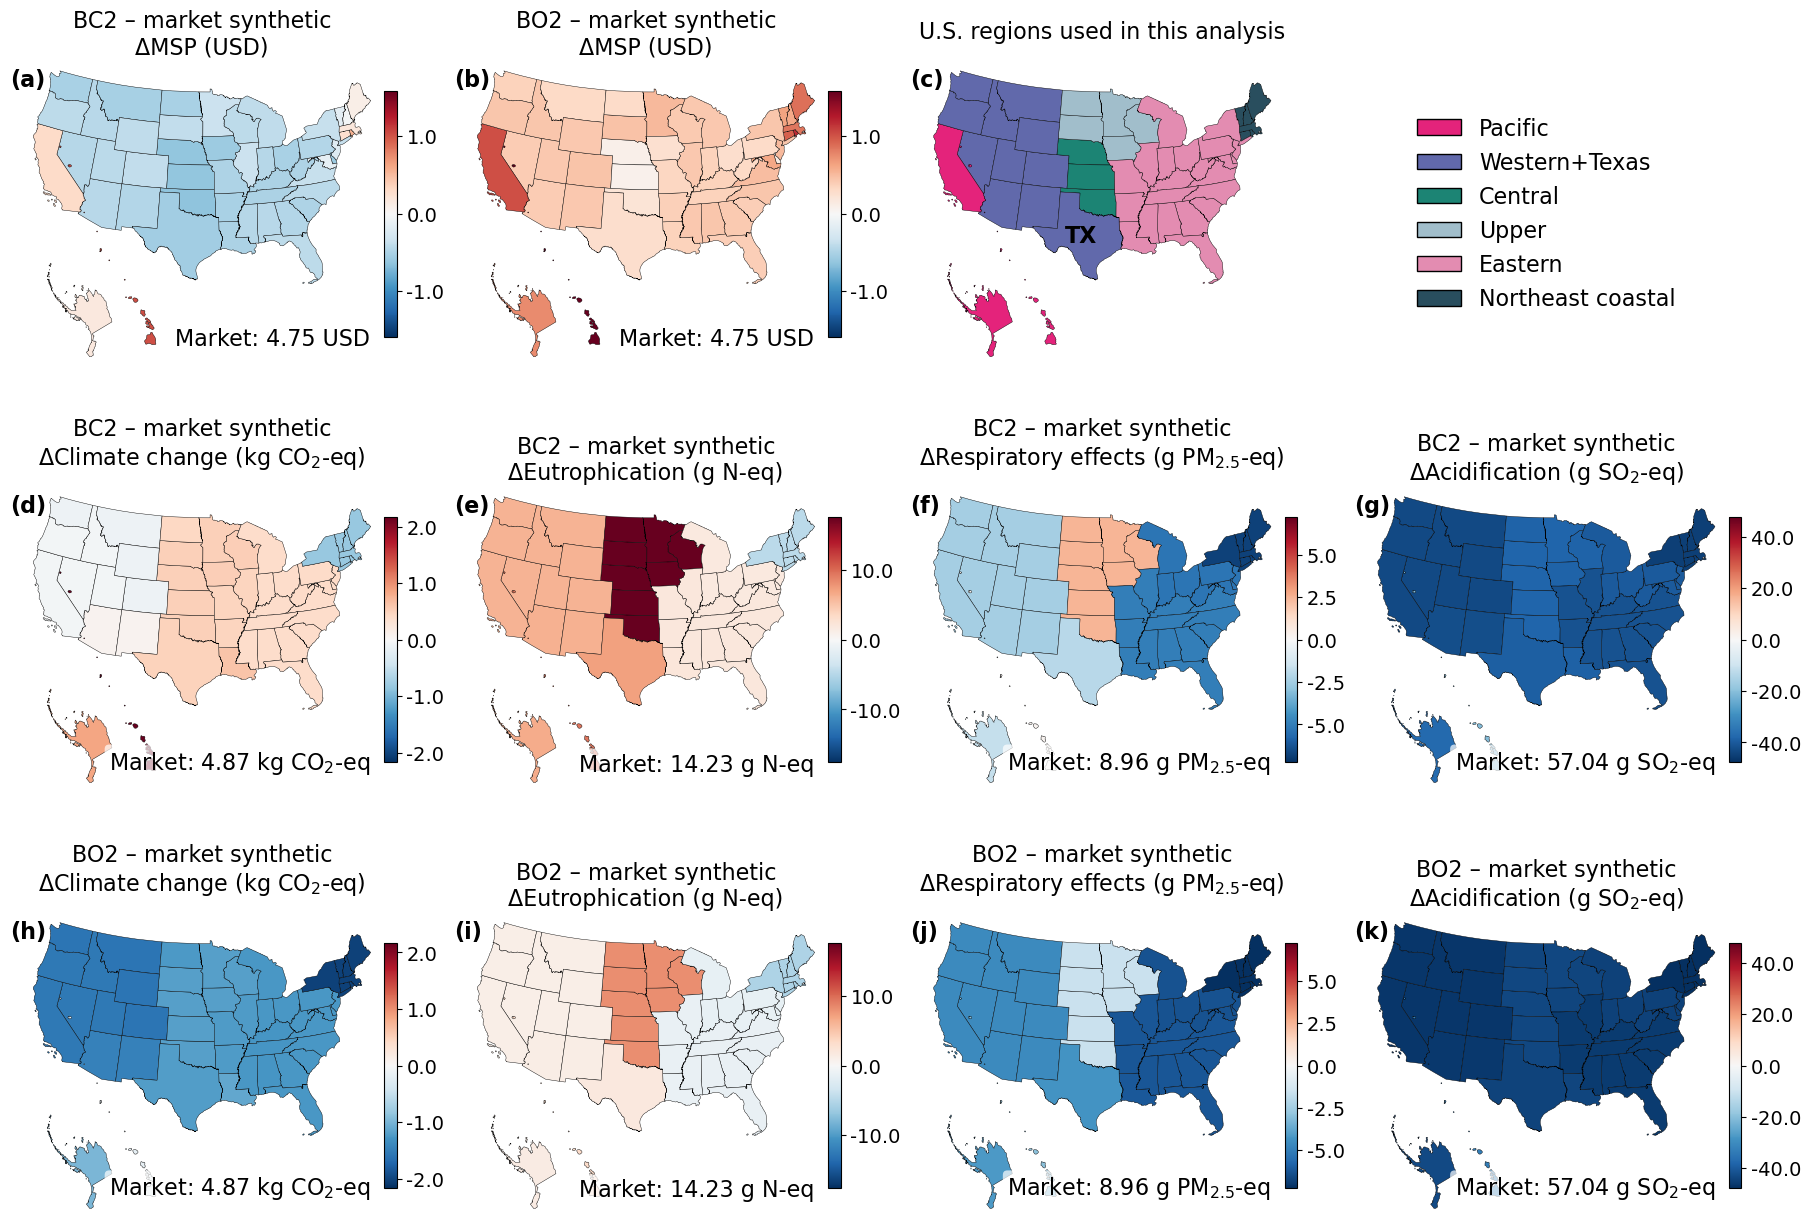

In [82]:

fig, axes, scale_meta = plot_current_spatial_legacy_scheme(
    states,
    delta_plot,
    region_def,
    market_kind=MARKET_KIND,
)

display(pd.DataFrame(scale_meta).T.rename_axis("metric"))

png_path = OUTPUT_DIR / "figure5_legacy_scheme_current_data.png"
pdf_path = OUTPUT_DIR / "figure5_legacy_scheme_current_data.pdf"

if SAVE_PNG:
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    print("Saved:", png_path)

if SAVE_PDF:
    fig.savefig(pdf_path, bbox_inches="tight")
    print("Saved:", pdf_path)

plt.show()


## 8. Region-level summary using the same current data

In [83]:

region_summary = (
    delta_plot
    .merge(region_def[["state", "region"]], on="state", how="left", validate="many_to_one")
    .groupby(["scenario", "region", "metric"], observed=True)["delta"]
    .agg(["mean", "std", "min", "max", "count"])
    .reset_index()
)

region_summary["region"] = pd.Categorical(
    region_summary["region"],
    categories=REGION_ORDER,
    ordered=True,
)
region_summary = region_summary.sort_values(["scenario", "metric", "region"])

summary_path = OUTPUT_DIR / "figure5_region_summary_current_data.csv"
region_summary.to_csv(summary_path, index=False)
print("Saved:", summary_path)

display(region_summary)


Saved: /mnt/g/My Drive/yale/Project-graphite/graphite_clean_project_spatial_v2_with_03b_legacy_visualization/graphite_clean_project_spatial_v2/result/spatial/figure5_region_summary_current_data.csv


,scenario,region,metric,mean,std,min,max,count
15,s_c2,Pacific,MSP,0.494294,0.456771,0.162525,1.015265,3
25,s_c2,Western+Texas,MSP,-0.456113,0.053303,-0.556407,-0.389260,11
0,s_c2,Central,MSP,-0.629728,0.005088,-0.634801,-0.624624,3
20,s_c2,Upper,MSP,-0.447465,0.095693,-0.578957,-0.341179,5
5,s_c2,Eastern,MSP,-0.417958,0.116365,-0.581674,-0.139544,23
10,s_c2,Northeast coastal,MSP,0.150735,0.251376,-0.157060,0.561451,6
16,s_c2,Pacific,acidification,-0.033717,0.011546,-0.043002,-0.020789,3
26,s_c2,Western+Texas,acidification,-0.042611,0.001056,-0.043053,-0.039490,11
1,s_c2,Central,acidification,-0.038426,0.000000,-0.038426,-0.038426,3
21,s_c2,Upper,acidification,-0.038568,0.000147,-0.038777,-0.038426,5



## Interpretation note

The six coarse regions shown in panel (c) are **not** the environmental-factor regions used in the LCA calculation.
The LCA itself continues to use the current state-specific assignments for:

- electricity: ecoinvent U.S. electricity regions;
- diesel: PADD regions;
- natural gas: dominant gas basins.

The coarse six-region grouping is retained only because it was part of the old manuscript visualization and region-level summary.


## 9. Supporting-information coverage: all pathways and both market benchmarks

The main figure remains **BC2/BO2 versus market synthetic graphite**.

For SI, this section deliberately separates two questions:

1. **Legacy five-metric view** — MSP plus the same four environmental categories used in the main figure.
   We reproduce the identical 3×4 layout for:
   - BC2/BO2 versus natural graphite;
   - BC1/BO1 versus synthetic graphite;
   - BC1/BO1 versus natural graphite.

2. **Remaining LCIA categories** — every canonical category not already shown in the main figure
   (currently freshwater ecotoxicity and smog). These are shown for **BC1, BC2, BO1, and BO2**
   against **both synthetic and natural graphite**.

This keeps the main-text visual unchanged while making the SI comparison complete.


In [84]:
ALL_ENV_CATEGORIES = [c for c in CANON_IMPACTS if c in state_lca.columns]
SI_ENV_CATEGORIES = [c for c in ALL_ENV_CATEGORIES if c not in ENV_CATEGORIES]

missing_units = [c for c in ALL_ENV_CATEGORIES if c not in BASE_UNITS]
missing_names = [c for c in ALL_ENV_CATEGORIES if c not in PRETTY_NAMES]
if missing_units or missing_names:
    raise KeyError(
        f"Update visualization metadata. Missing units={missing_units}; "
        f"missing pretty names={missing_names}"
    )

print("All canonical environmental categories:", ALL_ENV_CATEGORIES)
print("Main-text environmental categories:", ENV_CATEGORIES)
print("SI-only environmental categories:", SI_ENV_CATEGORIES)
print("Pathways:", {s: SC_LABEL.get(s, s) for s in ALL_SCENARIOS})
print("Market benchmarks:", MARKET_KINDS)


All canonical environmental categories: ['climate change', 'acidification', 'eutrophication', 'ecotoxicity: freshwater', 'particulate matter formation', 'photochemical oxidant formation']
Main-text environmental categories: ['climate change', 'eutrophication', 'particulate matter formation', 'acidification']
SI-only environmental categories: ['ecotoxicity: freshwater', 'photochemical oxidant formation']
Pathways: {'s_c1': 'BC1', 's_c2': 'BC2', 's_o1': 'BO1', 's_o2': 'BO2'}
Market benchmarks: ('synthetic', 'natural')


### 9.1 Legacy 3×4 SI figures for the additional pathway/market combinations

The function used for the main figure is reused without changing the calculation logic.
Only the scenario pair and market benchmark change.


Saved: /mnt/g/My Drive/yale/Project-graphite/graphite_clean_project_spatial_v2_with_03b_legacy_visualization/graphite_clean_project_spatial_v2/result/spatial/figureS_legacy_BC2_BO2_vs_natural.png
Saved: /mnt/g/My Drive/yale/Project-graphite/graphite_clean_project_spatial_v2_with_03b_legacy_visualization/graphite_clean_project_spatial_v2/result/spatial/figureS_legacy_BC2_BO2_vs_natural.pdf


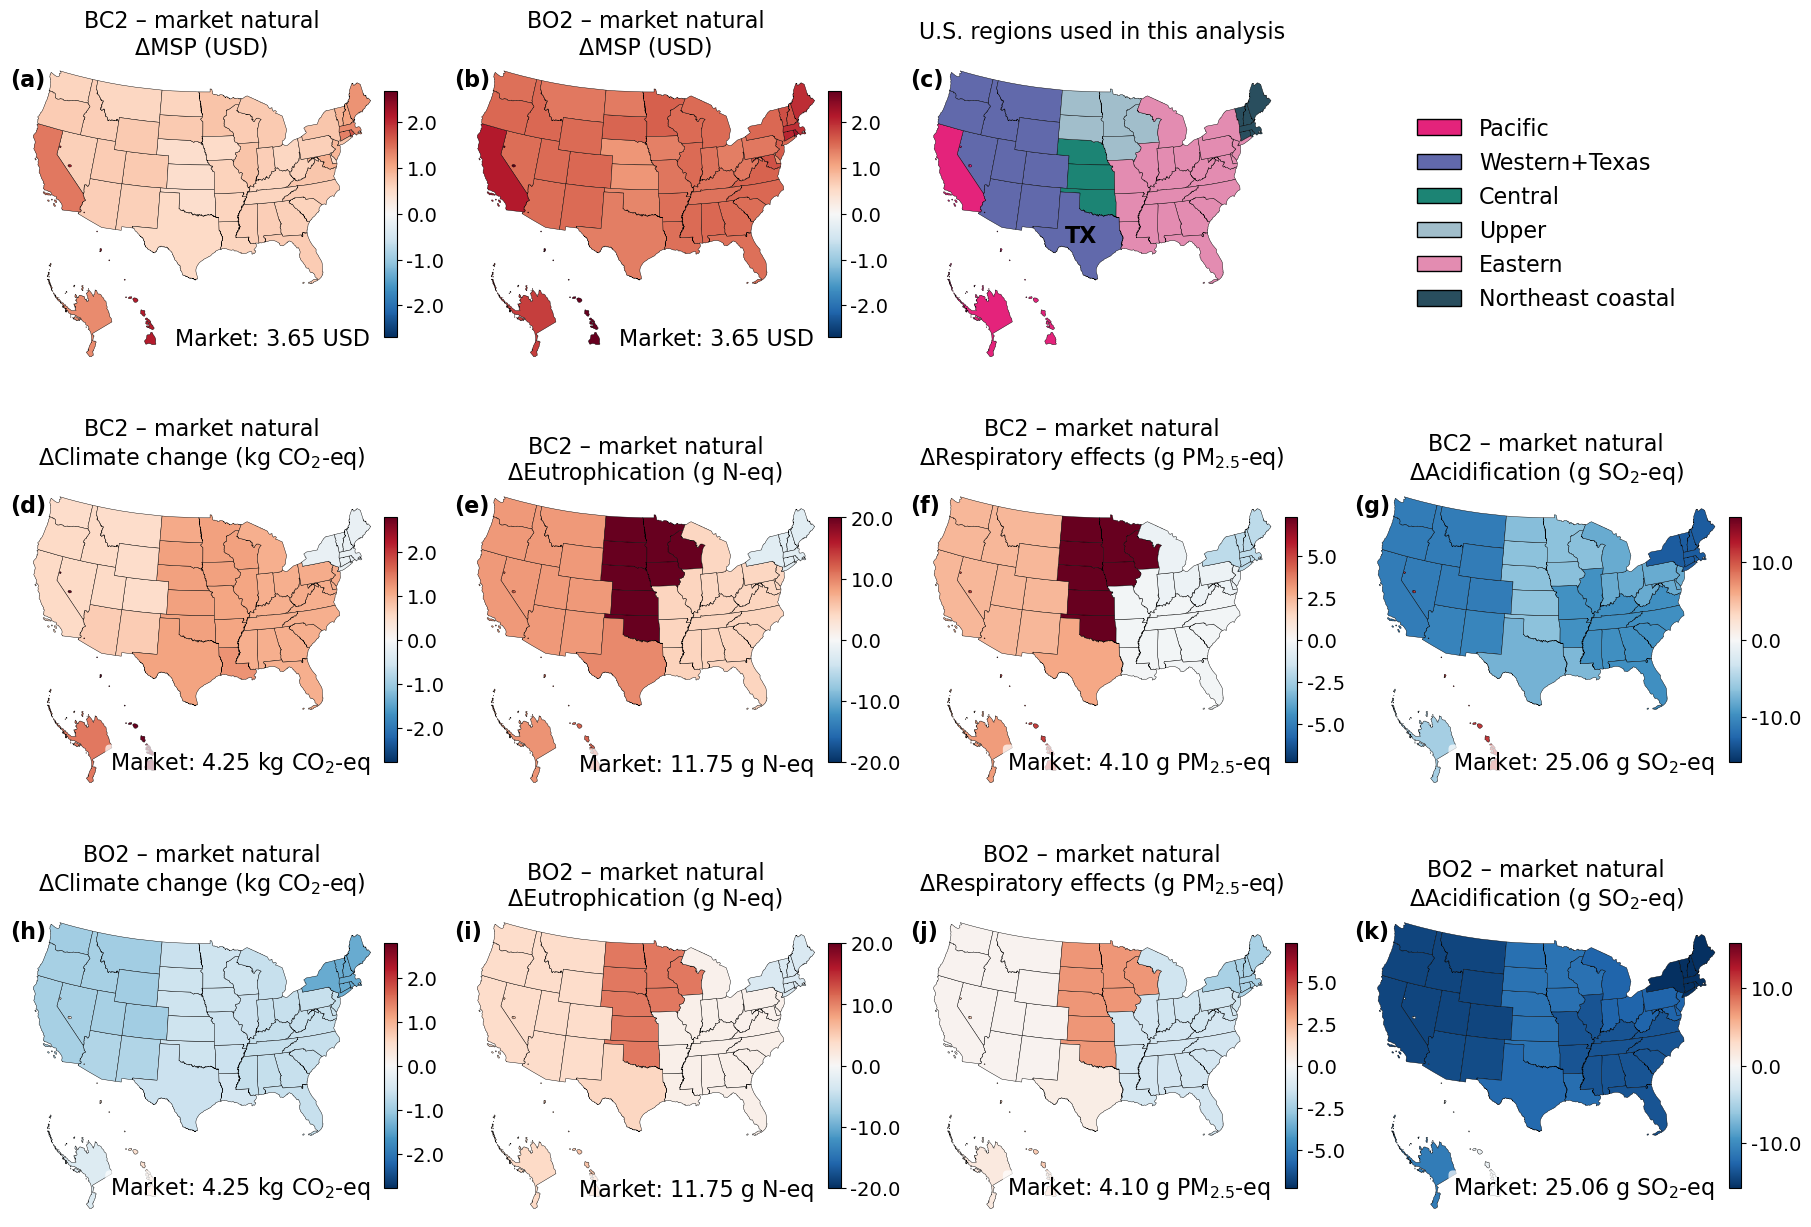

Saved: /mnt/g/My Drive/yale/Project-graphite/graphite_clean_project_spatial_v2_with_03b_legacy_visualization/graphite_clean_project_spatial_v2/result/spatial/figureS_legacy_BC1_BO1_vs_synthetic.png
Saved: /mnt/g/My Drive/yale/Project-graphite/graphite_clean_project_spatial_v2_with_03b_legacy_visualization/graphite_clean_project_spatial_v2/result/spatial/figureS_legacy_BC1_BO1_vs_synthetic.pdf


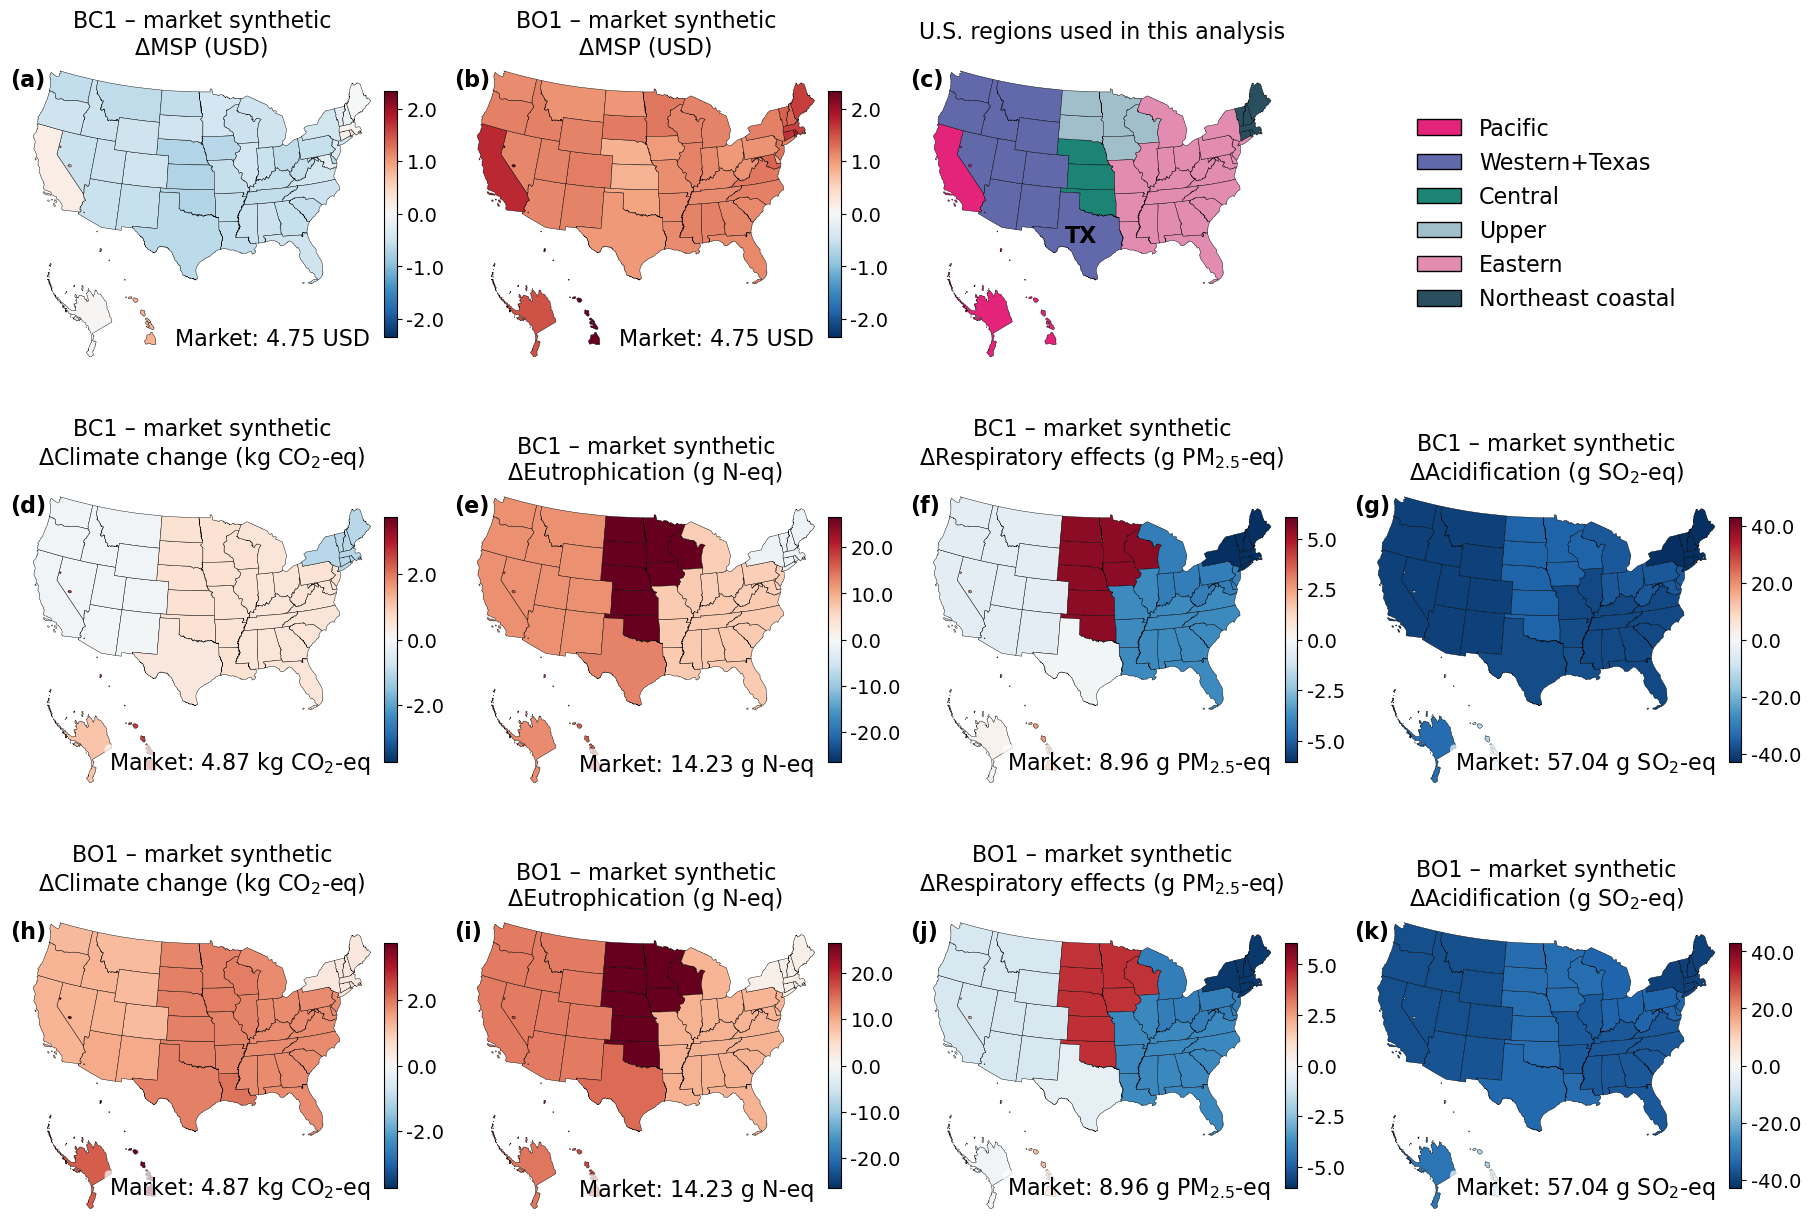

Saved: /mnt/g/My Drive/yale/Project-graphite/graphite_clean_project_spatial_v2_with_03b_legacy_visualization/graphite_clean_project_spatial_v2/result/spatial/figureS_legacy_BC1_BO1_vs_natural.png
Saved: /mnt/g/My Drive/yale/Project-graphite/graphite_clean_project_spatial_v2_with_03b_legacy_visualization/graphite_clean_project_spatial_v2/result/spatial/figureS_legacy_BC1_BO1_vs_natural.pdf


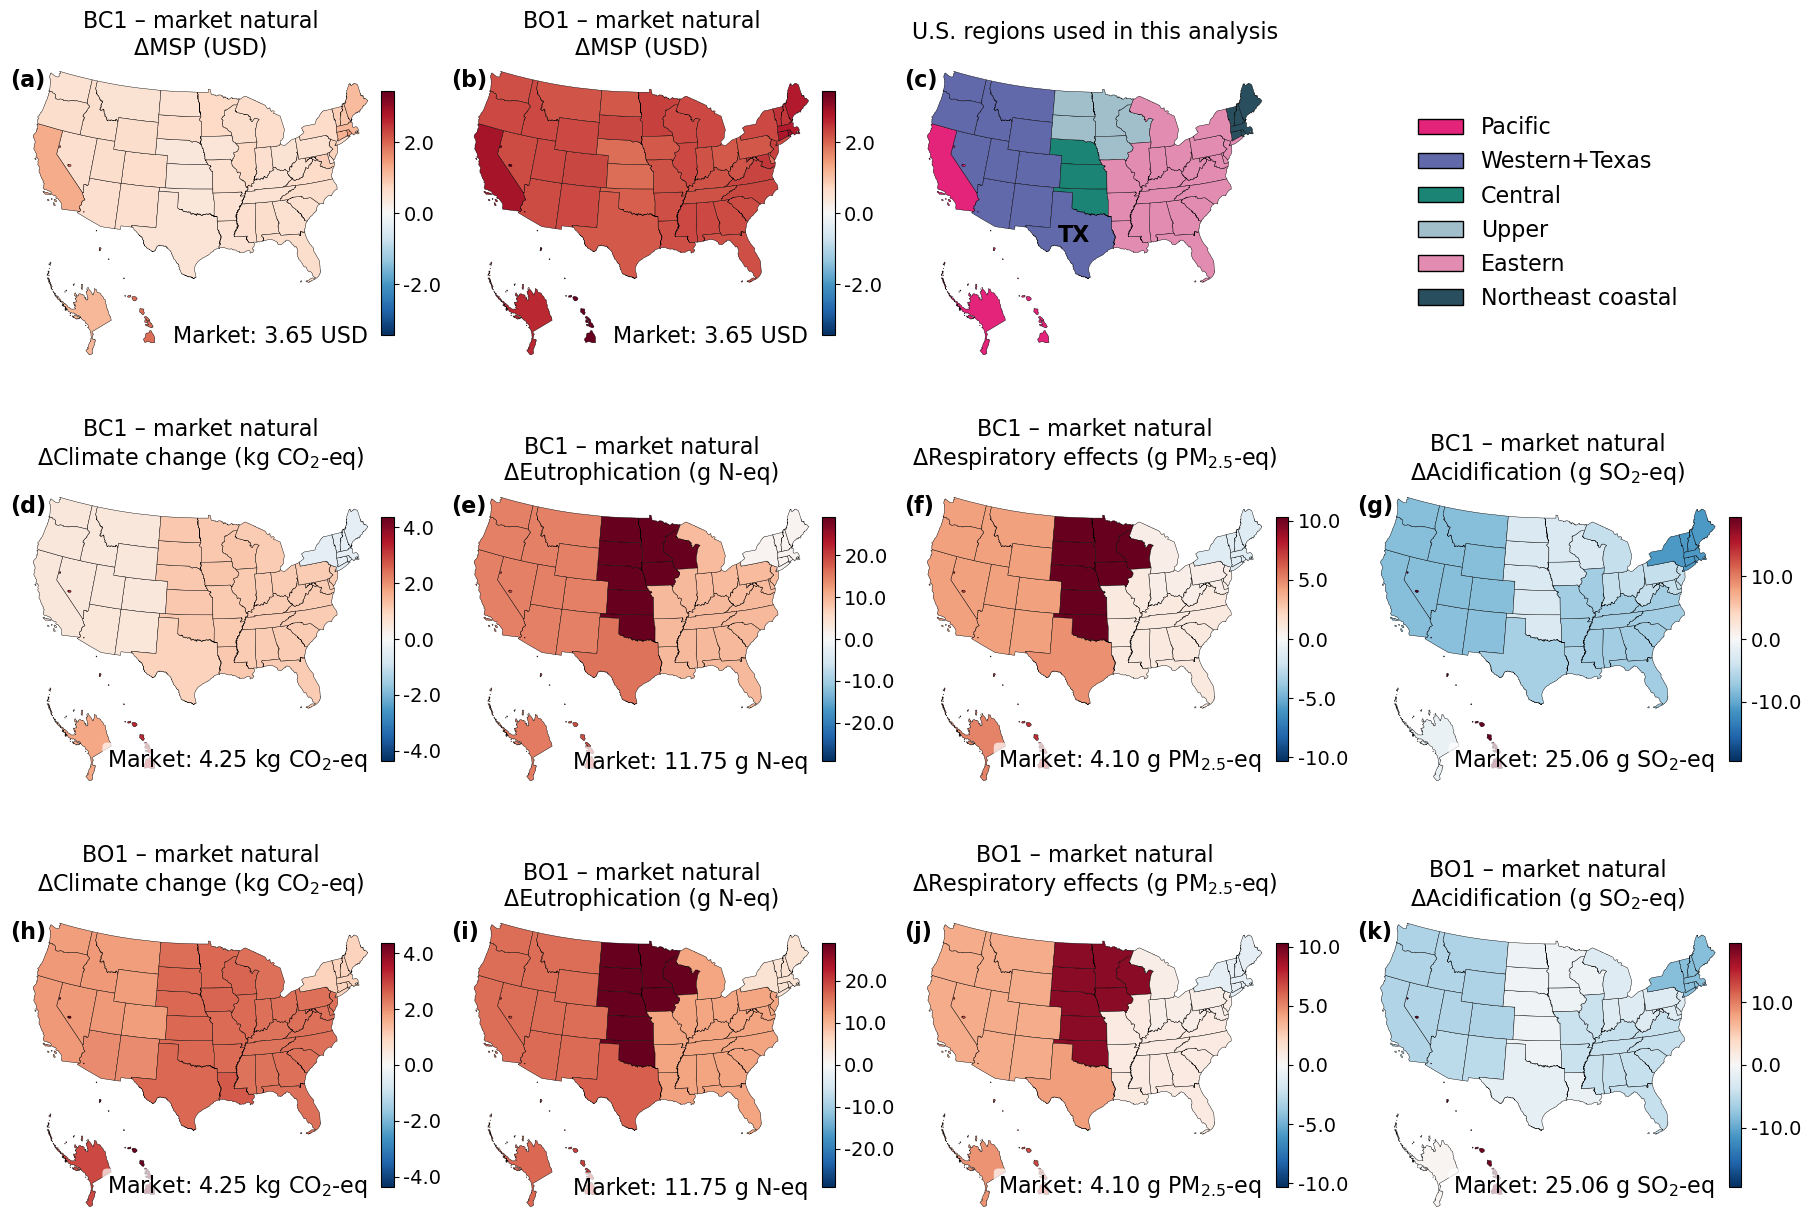

multiplier             unit
comparison           metric                                                  
BC2_BO2_vs_natural   MSP                                 1.0              USD
                     climate change                      1.0     kg CO$_2$-eq
                     eutrophication                   1000.0           g N-eq
                     particulate matter formation     1000.0  g PM$_{2.5}$-eq
                     acidification                    1000.0      g SO$_2$-eq
BC1_BO1_vs_synthetic MSP                                 1.0              USD
                     climate change                      1.0     kg CO$_2$-eq
                     eutrophication                   1000.0           g N-eq
                     particulate matter formation     1000.0  g PM$_{2.5}$-eq
                     acidification                    1000.0      g SO$_2$-eq
BC1_BO1_vs_natural   MSP                                 1.0              USD
                     climate change                      1.0     kg CO$_2$-eq
                     eutrophication                   1000.0           g N-eq
                     particulate matter formation     1000.0  g PM$_{2.5}$-eq
                     acidification                    1000.0      g SO$_2$-eq

In [85]:
legacy_si_specs = [
    {
        "name": "BC2_BO2_vs_natural",
        "scenarios": SCENARIO_PAIRS["BC2_BO2"],
        "market_kind": "natural",
        "filename": "figureS_legacy_BC2_BO2_vs_natural",
    },
    {
        "name": "BC1_BO1_vs_synthetic",
        "scenarios": SCENARIO_PAIRS["BC1_BO1"],
        "market_kind": "synthetic",
        "filename": "figureS_legacy_BC1_BO1_vs_synthetic",
    },
    {
        "name": "BC1_BO1_vs_natural",
        "scenarios": SCENARIO_PAIRS["BC1_BO1"],
        "market_kind": "natural",
        "filename": "figureS_legacy_BC1_BO1_vs_natural",
    },
]

legacy_si_scale_metadata = {}

for spec in legacy_si_specs:
    d = delta_tables[spec["market_kind"]]
    d_plot = d.loc[
        d["scenario"].isin(spec["scenarios"])
        & d["metric"].isin(["MSP", *ENV_CATEGORIES])
    ].copy()

    fig_si, _, scale_meta_si = plot_current_spatial_legacy_scheme(
        states,
        d_plot,
        region_def,
        scenario_top=spec["scenarios"][0],
        scenario_bottom=spec["scenarios"][1],
        env_categories=ENV_CATEGORIES,
        market_kind=spec["market_kind"],
    )
    legacy_si_scale_metadata[spec["name"]] = scale_meta_si

    if SAVE_PNG:
        p = OUTPUT_DIR / f'{spec["filename"]}.png'
        fig_si.savefig(p, dpi=300, bbox_inches="tight")
        print("Saved:", p)
    if SAVE_PDF:
        p = OUTPUT_DIR / f'{spec["filename"]}.pdf'
        fig_si.savefig(p, bbox_inches="tight")
        print("Saved:", p)

    plt.show()
    plt.close(fig_si)

display(
    pd.concat(
        {
            name: pd.DataFrame(meta).T
            for name, meta in legacy_si_scale_metadata.items()
        },
        names=["comparison", "metric"],
    )
)


### 9.2 Remaining LCIA categories for BC1, BC2, BO1, and BO2

Rows are pathways and columns are the LCIA categories omitted from the main figure.
Within each market-specific figure, the BC1/BC2/BO1/BO2 maps for a given impact category share
the same dynamic unit and symmetric color range, making pathway comparisons direct.


### 9.2 Remaining LCIA categories in the same legacy map style

The two LCIA categories omitted from the main figure are shown using the **same
per-panel visualization grammar as the main 03b maps**.

To keep pathway grouping consistent with the rest of the notebook, this section
creates four separate **2×2** SI figures:

- BC2 / BO2 versus synthetic graphite;
- BC2 / BO2 versus natural graphite;
- BC1 / BO1 versus synthetic graphite;
- BC1 / BO1 versus natural graphite.

Within each figure, rows are the two pathways and columns are the remaining
LCIA categories (currently freshwater ecotoxicity and smog). Each panel has
its own colorbar, title, panel letter, and market benchmark annotation, exactly
as in the legacy 3×4 figure.


In [86]:
def plot_si_remaining_impacts_legacy_pair(
    states_gdf,
    delta_df,
    impact_categories,
    *,
    scenarios,
    market_kind,
    delta_cmap=DELTA_CMAP,
    figsize_per_plot=FIGSIZE_PER_PLOT,
    title_fs=TITLE_FS,
    panel_label_fs=PANEL_LABEL_FS,
    market_text_fs=MARKET_TEXT_FS,
):
    """
    Plot the SI-only LCIA categories using the SAME map grammar as the
    legacy 03b main figure.

    Layout:
      row 1 = first pathway in the pair (BC1 or BC2)
      row 2 = second pathway in the pair (BO1 or BO2)
      col 1 = first SI-only impact
      col 2 = second SI-only impact

    Each panel has:
      * its own colorbar, as in the main 03b figure;
      * the same compact-U.S. geometry;
      * the same two-line title style;
      * the same bottom-right market benchmark annotation;
      * the same panel-label placement;
      * one symmetric color range per metric, shared across the TWO
        pathways in this figure.
    """
    impact_categories = list(impact_categories)
    scenarios = list(scenarios)
    market_kind = str(market_kind).strip().lower()

    if len(impact_categories) != 2:
        raise ValueError(
            "This legacy-pair SI layout expects exactly two SI-only impact categories."
        )
    if len(scenarios) != 2:
        raise ValueError(
            "This legacy-pair SI layout expects exactly two pathways."
        )
    if market_kind not in {"synthetic", "natural"}:
        raise ValueError("market_kind must be 'synthetic' or 'natural'.")

    observed_markets = set(
        delta_df["market_type"].dropna().astype(str).str.lower().unique()
    )
    if observed_markets and observed_markets != {market_kind}:
        raise ValueError(
            f"delta_df market_type={sorted(observed_markets)} "
            f"does not match market_kind={market_kind!r}"
        )

    # -------------------------------------------------------------
    # Geometry — exactly the same compact-U.S. helper as main figure
    # -------------------------------------------------------------
    g_states = (
        states_gdf[["state", "geometry"]]
        .drop_duplicates("state")
        .copy()
    )
    g_states["state"] = g_states["state"].astype(str).str.upper()
    g_states = compact_us_geometries(g_states)
    n_states = g_states["state"].nunique()

    # -------------------------------------------------------------
    # Select this pathway pair × these two SI metrics
    # -------------------------------------------------------------
    selected = delta_df.loc[
        delta_df["scenario"].isin(scenarios)
        & delta_df["metric"].isin(impact_categories)
    ].copy()

    expected_rows = len(scenarios) * len(impact_categories) * n_states
    if len(selected) != expected_rows:
        counts = (
            selected.groupby(["scenario", "metric"])
            .size()
            .rename("n")
            .reset_index()
        )
        raise ValueError(
            "Unexpected SI delta-table size. "
            f"Got {len(selected)} rows; expected {expected_rows}.\n"
            + counts.to_string(index=False)
        )

    # -------------------------------------------------------------
    # Dynamic units — same rule as main 03b figure
    # -------------------------------------------------------------
    scaled = selected.copy()
    scale_meta = {}

    for metric in impact_categories:
        d = scaled.loc[scaled["metric"].eq(metric)]

        values_for_scale = np.r_[
            pd.to_numeric(d["delta"], errors="coerce").to_numpy(float),
            pd.to_numeric(d["benchmark"], errors="coerce").to_numpy(float),
        ]

        multiplier, unit = choose_dynamic_scale(
            values_for_scale,
            BASE_UNITS[metric],
        )
        scale_meta[metric] = {
            "multiplier": multiplier,
            "unit": unit,
        }

        mask = scaled["metric"].eq(metric)
        scaled.loc[mask, "delta_scaled"] = (
            pd.to_numeric(
                scaled.loc[mask, "delta"],
                errors="coerce",
            )
            * multiplier
        )
        scaled.loc[mask, "benchmark_scaled"] = (
            pd.to_numeric(
                scaled.loc[mask, "benchmark"],
                errors="coerce",
            )
            * multiplier
        )

    # Symmetric range per metric shared across the TWO pathways,
    # matching the main 03b comparison logic.
    vmax_by_metric = {}
    for metric in impact_categories:
        vals = pd.to_numeric(
            scaled.loc[
                scaled["metric"].eq(metric),
                "delta_scaled",
            ],
            errors="coerce",
        ).dropna()

        if vals.empty:
            raise ValueError(
                f"No finite delta values found for {metric!r}."
            )

        vmax = float(vals.abs().max())
        vmax_by_metric[metric] = vmax if vmax > 0 else 1.0

    # -------------------------------------------------------------
    # 2 × 2 legacy-style figure.
    #
    # constrained_layout is safe here because there are only four
    # panels; the collapse problem occurred in the earlier 4 × 2
    # figure with eight colorbars and long titles.
    # -------------------------------------------------------------
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(
            figsize_per_plot[0] * 2,
            figsize_per_plot[1] * 2,
        ),
        subplot_kw={"aspect": "equal"},
        constrained_layout=True,
        squeeze=False,
    )

    panel_label_map = {
        (0, 0): "(a)",
        (0, 1): "(b)",
        (1, 0): "(c)",
        (1, 1): "(d)",
    }

    gxmin, gymin, gxmax, gymax = g_states.total_bounds
    px = 0.02 * (gxmax - gxmin)
    py = 0.03 * (gymax - gymin)

    market_label = f"market {market_kind}"

    # -------------------------------------------------------------
    # Draw each panel using the same details as draw_delta_panel()
    # in plot_current_spatial_legacy_scheme().
    # -------------------------------------------------------------
    for r, scenario in enumerate(scenarios):
        for c, metric in enumerate(impact_categories):
            ax = axes[r, c]

            d = scaled.loc[
                scaled["scenario"].eq(scenario)
                & scaled["metric"].eq(metric),
                ["state", "delta_scaled", "benchmark_scaled"],
            ].copy()

            m = g_states.merge(
                d,
                on="state",
                how="left",
                validate="one_to_one",
            )

            n_mapped = int(m["delta_scaled"].notna().sum())
            if n_mapped != n_states:
                missing_states = m.loc[
                    m["delta_scaled"].isna(),
                    "state",
                ].tolist()
                raise ValueError(
                    f"{scenario}/{metric}: mapped "
                    f"{n_mapped}/{n_states} states. "
                    f"Missing: {missing_states}"
                )

            vmax = vmax_by_metric[metric]
            norm = mcolors.TwoSlopeNorm(
                vmin=-vmax,
                vcenter=0.0,
                vmax=vmax,
            )

            vals = pd.to_numeric(
                m["delta_scaled"],
                errors="coerce",
            )
            fmt_str = legend_fmt_for_values(
                vals,
                small_decimals=1,
            )
            formatter = FuncFormatter(
                lambda x, pos, f=fmt_str: f.format(x)
            )

            m.plot(
                column="delta_scaled",
                ax=ax,
                cmap=delta_cmap,
                edgecolor="black",
                linewidth=0.3,
                legend=False,
                norm=norm,
                missing_kwds={"color": "lightgrey"},
            )

            sm = cm.ScalarMappable(
                norm=norm,
                cmap=delta_cmap,
            )
            sm.set_array(vals.to_numpy(float))

            cb = fig.colorbar(
                sm,
                ax=ax,
                fraction=0.035,
                pad=0.02,
                format=formatter,
            )
            cb.ax.tick_params(labelsize=14)

            ax.set_xlim(gxmin - px, gxmax + px)
            ax.set_ylim(gymin - py, gymax + py)
            ax.set_axis_off()

            unit = scale_meta[metric]["unit"]
            pretty = PRETTY_NAMES[metric]
            sc_short = SC_LABEL.get(scenario, scenario)

            ax.set_title(
                f"{sc_short} – {market_label}\n"
                f"Δ{pretty} ({unit})",
                fontsize=title_fs,
            )

            benchmark = pd.to_numeric(
                d["benchmark_scaled"],
                errors="coerce",
            ).dropna()

            if len(benchmark):
                market_value = float(benchmark.iloc[0])
                benchmark_fmt = legend_fmt_for_values(
                    [market_value],
                    small_decimals=1,
                    large_decimals=0,
                )
                ax.text(
                    0.98,
                    0.05,
                    f"Market: {benchmark_fmt.format(market_value)} {unit}",
                    transform=ax.transAxes,
                    ha="right",
                    va="bottom",
                    fontsize=market_text_fs,
                    bbox=dict(
                        boxstyle="round,pad=0.2",
                        facecolor="white",
                        edgecolor="none",
                        alpha=0.7,
                    ),
                )

            ax.text(
                0.0005,
                0.98,
                panel_label_map[(r, c)],
                transform=_panel_label_transform(ax),
                ha="left",
                va="top",
                fontsize=panel_label_fs,
                fontweight="bold",
                clip_on=False,
            )

    return fig, axes, scale_meta, scaled

Saved: /mnt/g/My Drive/yale/Project-graphite/graphite_clean_project_spatial_v2_with_03b_legacy_visualization/graphite_clean_project_spatial_v2/result/spatial/figureS_remaining_impacts_BC2_BO2_vs_synthetic.png
Saved: /mnt/g/My Drive/yale/Project-graphite/graphite_clean_project_spatial_v2_with_03b_legacy_visualization/graphite_clean_project_spatial_v2/result/spatial/figureS_remaining_impacts_BC2_BO2_vs_synthetic.pdf


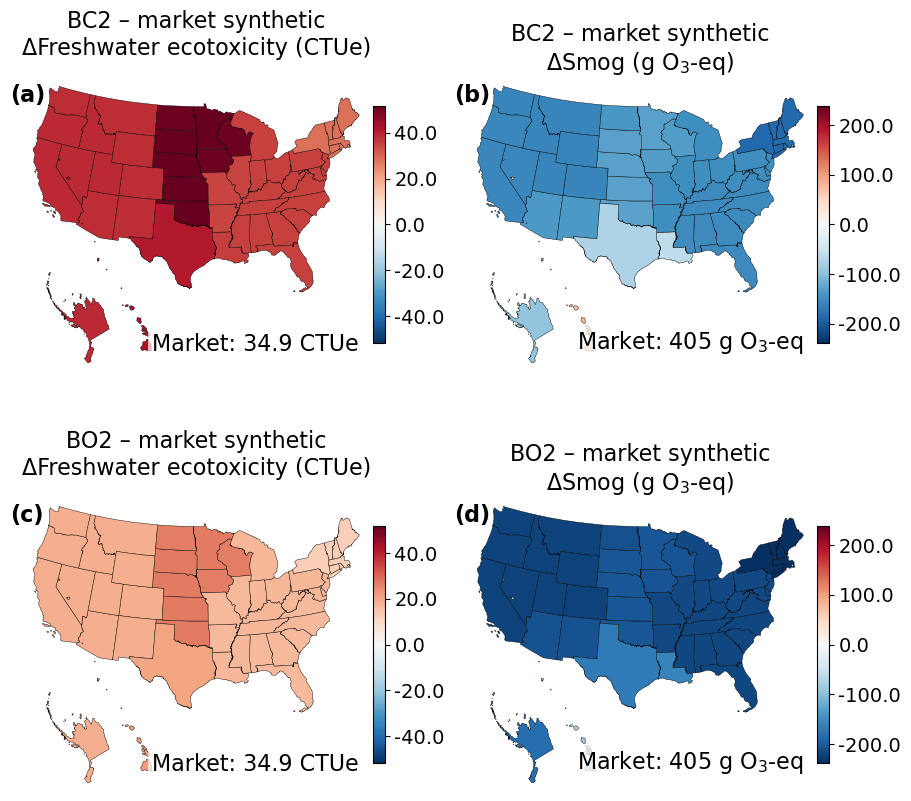

Saved: /mnt/g/My Drive/yale/Project-graphite/graphite_clean_project_spatial_v2_with_03b_legacy_visualization/graphite_clean_project_spatial_v2/result/spatial/figureS_remaining_impacts_BC2_BO2_vs_natural.png
Saved: /mnt/g/My Drive/yale/Project-graphite/graphite_clean_project_spatial_v2_with_03b_legacy_visualization/graphite_clean_project_spatial_v2/result/spatial/figureS_remaining_impacts_BC2_BO2_vs_natural.pdf


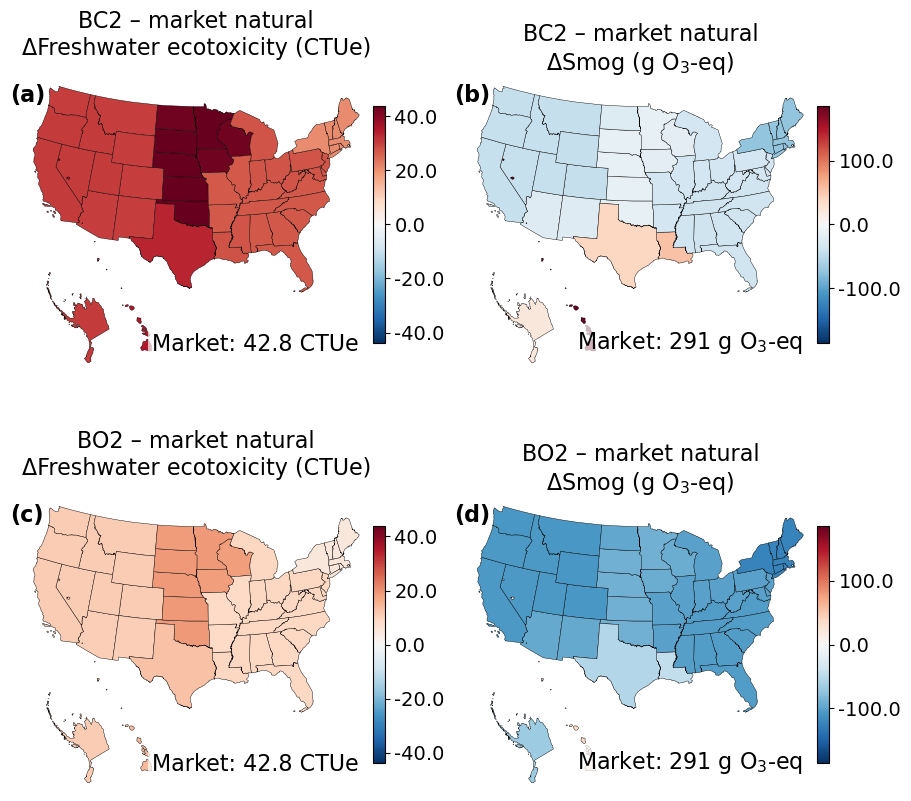

Saved: /mnt/g/My Drive/yale/Project-graphite/graphite_clean_project_spatial_v2_with_03b_legacy_visualization/graphite_clean_project_spatial_v2/result/spatial/figureS_remaining_impacts_BC1_BO1_vs_synthetic.png
Saved: /mnt/g/My Drive/yale/Project-graphite/graphite_clean_project_spatial_v2_with_03b_legacy_visualization/graphite_clean_project_spatial_v2/result/spatial/figureS_remaining_impacts_BC1_BO1_vs_synthetic.pdf


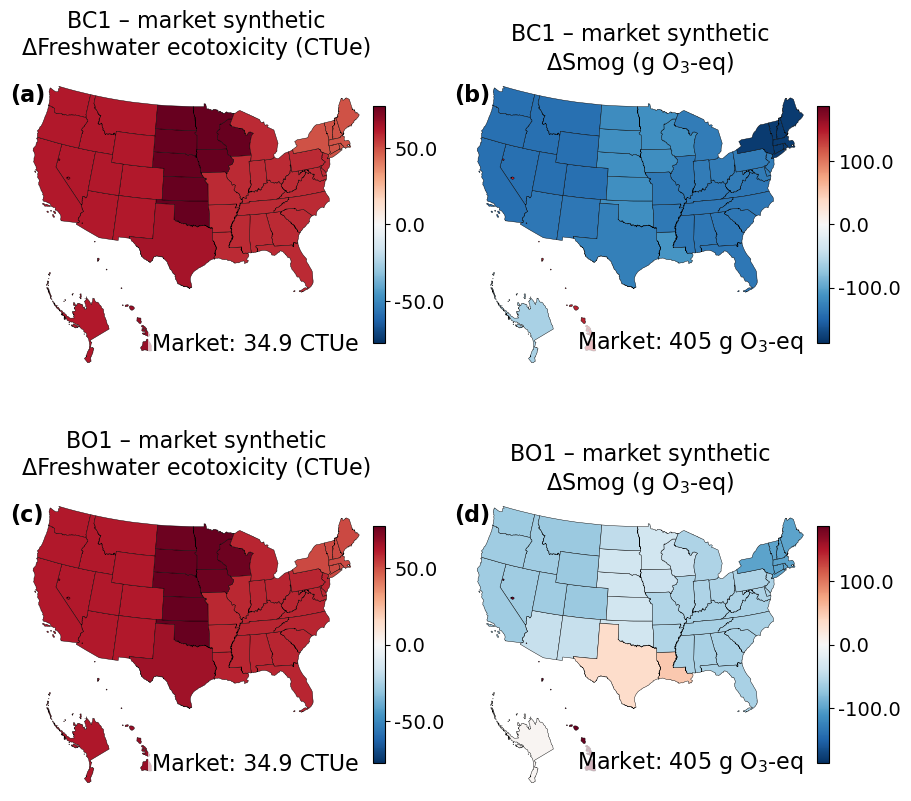

Saved: /mnt/g/My Drive/yale/Project-graphite/graphite_clean_project_spatial_v2_with_03b_legacy_visualization/graphite_clean_project_spatial_v2/result/spatial/figureS_remaining_impacts_BC1_BO1_vs_natural.png
Saved: /mnt/g/My Drive/yale/Project-graphite/graphite_clean_project_spatial_v2_with_03b_legacy_visualization/graphite_clean_project_spatial_v2/result/spatial/figureS_remaining_impacts_BC1_BO1_vs_natural.pdf


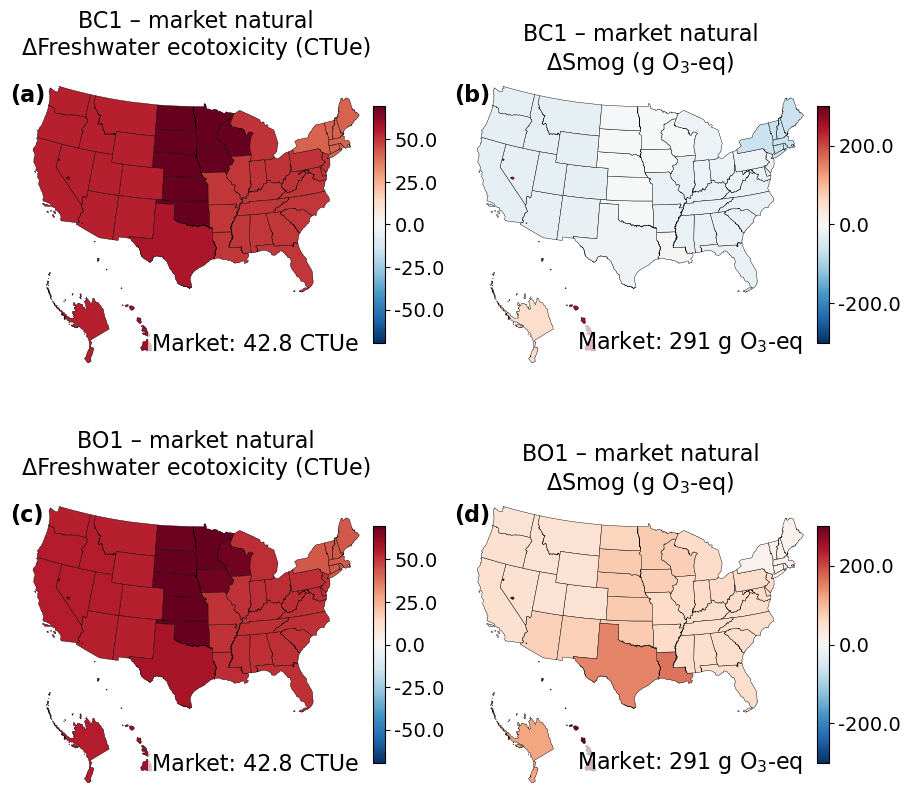

multiplier        unit
comparison        metric                                                
synthetic/BC2_BO2 ecotoxicity: freshwater                1.0        CTUe
                  photochemical oxidant formation     1000.0  g O$_3$-eq
natural/BC2_BO2   ecotoxicity: freshwater                1.0        CTUe
                  photochemical oxidant formation     1000.0  g O$_3$-eq
synthetic/BC1_BO1 ecotoxicity: freshwater                1.0        CTUe
                  photochemical oxidant formation     1000.0  g O$_3$-eq
natural/BC1_BO1   ecotoxicity: freshwater                1.0        CTUe
                  photochemical oxidant formation     1000.0  g O$_3$-eq

In [87]:
remaining_si_outputs = {}
remaining_si_scale_metadata = {}

remaining_si_specs = [
    {
        "pair_name": "BC2_BO2",
        "scenarios": SCENARIO_PAIRS["BC2_BO2"],
        "market_kind": "synthetic",
    },
    {
        "pair_name": "BC2_BO2",
        "scenarios": SCENARIO_PAIRS["BC2_BO2"],
        "market_kind": "natural",
    },
    {
        "pair_name": "BC1_BO1",
        "scenarios": SCENARIO_PAIRS["BC1_BO1"],
        "market_kind": "synthetic",
    },
    {
        "pair_name": "BC1_BO1",
        "scenarios": SCENARIO_PAIRS["BC1_BO1"],
        "market_kind": "natural",
    },
]

for spec in remaining_si_specs:
    market_kind = spec["market_kind"]
    pair_name = spec["pair_name"]
    scenarios = spec["scenarios"]

    d = delta_tables[market_kind]

    fig_si, _, scale_meta_si, scaled_si = (
        plot_si_remaining_impacts_legacy_pair(
            states,
            d,
            SI_ENV_CATEGORIES,
            scenarios=scenarios,
            market_kind=market_kind,
        )
    )

    key = (market_kind, pair_name)
    remaining_si_outputs[key] = scaled_si
    remaining_si_scale_metadata[key] = scale_meta_si

    stem = (
        f"figureS_remaining_impacts_"
        f"{pair_name}_vs_{market_kind}"
    )

    if SAVE_PNG:
        p = OUTPUT_DIR / f"{stem}.png"
        fig_si.savefig(
            p,
            dpi=300,
            bbox_inches="tight",
        )
        print("Saved:", p)

    if SAVE_PDF:
        p = OUTPUT_DIR / f"{stem}.pdf"
        fig_si.savefig(
            p,
            bbox_inches="tight",
        )
        print("Saved:", p)

    plt.show()
    plt.close(fig_si)

display(
    pd.concat(
        {
            f"{market_kind}/{pair_name}": pd.DataFrame(meta).T
            for (market_kind, pair_name), meta
            in remaining_si_scale_metadata.items()
        },
        names=["comparison", "metric"],
    )
)

## 10. SI data exports: every pathway × both markets × every metric

These exports are deliberately broader than the figures so the SI has an auditable numeric record.

- `tableS_spatial_all_pathways_both_markets_all_metrics.csv`:
  BC1/BC2/BO1/BO2 × synthetic/natural × MSP + all six LCIA categories × states.
- `tableS_spatial_all_pathways_both_markets_region_summary.csv`:
  the same comparisons summarized over the six legacy presentation regions.
- `tableS_spatial_remaining_impacts_display_units.csv`:
  SI-only environmental categories with the exact display multiplier/unit used in the maps.


In [88]:
all_comparisons = pd.concat(
    [delta_tables[k] for k in MARKET_KINDS],
    ignore_index=True,
)
all_metrics = ["MSP", *ALL_ENV_CATEGORIES]

all_comparisons = all_comparisons.loc[
    all_comparisons["scenario"].isin(ALL_SCENARIOS)
    & all_comparisons["metric"].isin(all_metrics)
].copy()

assert not all_comparisons.duplicated(
    ["state", "scenario", "metric", "market_type", "price_stat"]
).any()

all_state_path = OUTPUT_DIR / "tableS_spatial_all_pathways_both_markets_all_metrics.csv"
all_comparisons.to_csv(all_state_path, index=False)
print("Saved:", all_state_path)

all_region_summary = (
    all_comparisons
    .merge(region_def[["state", "region"]], on="state", how="left", validate="many_to_one")
    .groupby(
        ["market_type", "scenario", "region", "metric"],
        observed=True,
    )["delta"]
    .agg(["mean", "std", "min", "max", "count"])
    .reset_index()
)
all_region_summary["region"] = pd.Categorical(
    all_region_summary["region"], categories=REGION_ORDER, ordered=True
)
all_region_summary = all_region_summary.sort_values(
    ["market_type", "scenario", "metric", "region"]
)

all_region_path = OUTPUT_DIR / "tableS_spatial_all_pathways_both_markets_region_summary.csv"
all_region_summary.to_csv(all_region_path, index=False)
print("Saved:", all_region_path)

remaining_display = []
for (market_kind, pair_name), scaled in remaining_si_outputs.items():
    temp = scaled.copy()
    meta = remaining_si_scale_metadata[(market_kind, pair_name)]
    temp["comparison_pair"] = pair_name
    temp["display_unit"] = temp["metric"].map(
        {k: v["unit"] for k, v in meta.items()}
    )
    temp["display_multiplier"] = temp["metric"].map(
        {k: v["multiplier"] for k, v in meta.items()}
    )
    remaining_display.append(temp)

remaining_display = pd.concat(remaining_display, ignore_index=True)
remaining_display_path = OUTPUT_DIR / "tableS_spatial_remaining_impacts_display_units.csv"
remaining_display.to_csv(remaining_display_path, index=False)
print("Saved:", remaining_display_path)

display(
    all_region_summary.groupby(["market_type", "scenario", "metric"], observed=True)["mean"]
    .agg(["min", "mean", "max"])
)


Saved: /mnt/g/My Drive/yale/Project-graphite/graphite_clean_project_spatial_v2_with_03b_legacy_visualization/graphite_clean_project_spatial_v2/result/spatial/tableS_spatial_all_pathways_both_markets_all_metrics.csv
Saved: /mnt/g/My Drive/yale/Project-graphite/graphite_clean_project_spatial_v2_with_03b_legacy_visualization/graphite_clean_project_spatial_v2/result/spatial/tableS_spatial_all_pathways_both_markets_region_summary.csv
Saved: /mnt/g/My Drive/yale/Project-graphite/graphite_clean_project_spatial_v2_with_03b_legacy_visualization/graphite_clean_project_spatial_v2/result/spatial/tableS_spatial_remaining_impacts_display_units.csv


min       mean  \
market_type scenario metric                                                  
natural     s_c1     MSP                               0.401780   0.787838   
                     acidification                    -0.011079  -0.004634   
                     climate change                   -0.426304   0.892993   
                     ecotoxicity: freshwater          41.396532  56.791618   
                     eutrophication                    0.000867   0.016378   
                     particulate matter formation     -0.001219   0.004994   
                     photochemical oxidant formation  -0.064406  -0.002780   
            s_c2     MSP                               0.470272   0.882294   
                     acidification                    -0.013209  -0.007946   
                     climate change                   -0.210131   0.878612   
                     ecotoxicity: freshwater          20.624048  33.038210   
                     eutrophication                   -0.002318   0.010104   
                     particulate matter formation     -0.001932   0.003048   
                     photochemical oxidant formation  -0.072585  -0.019698   
            s_o1     MSP                               1.964114   2.386996   
                     acidification                    -0.008309  -0.002443   
                     climate change                    1.016624   2.230490   
                     ecotoxicity: freshwater          43.395866  57.220922   
                     eutrophication                    0.004084   0.017905   
                     particulate matter formation     -0.001004   0.004538   
                     photochemical oxidant formation   0.014131   0.073376   
            s_o2     MSP                               1.227680   1.647463   
                     acidification                    -0.015842  -0.012633   
                     climate change                   -1.401966  -0.738532   
                     ecotoxicity: freshwater           4.985339  12.554453   
                     eutrophication                   -0.002986   0.004585   
                     particulate matter formation     -0.002389   0.000646   
                     photochemical oxidant formation  -0.124771  -0.092480   
synthetic   s_c1     MSP                              -0.698220  -0.312162   
                     acidification                    -0.043061  -0.036616   
                     climate change                   -1.044673   0.274624   
                     ecotoxicity: freshwater          49.277238  64.672325   
                     eutrophication                   -0.001615   0.013895   
                     particulate matter formation     -0.006072   0.000141   
                     photochemical oxidant formation  -0.178651  -0.117025   
            s_c2     MSP                              -0.629728  -0.217706   
                     acidification                    -0.045191  -0.039928   
                     climate change                   -0.828500   0.260243   
                     ecotoxicity: freshwater          28.504754  40.918917   
                     eutrophication                   -0.004801   0.007622   
                     particulate matter formation     -0.006785  -0.001805   
                     photochemical oxidant formation  -0.186829  -0.133942   
            s_o1     MSP                               0.864114   1.286996   
                     acidification                    -0.040291  -0.034425   
                     climate change                    0.398255   1.612121   
                     ecotoxicity: freshwater          51.276572  65.101628   
                     eutrophication                    0.001601   0.015423   
                     particulate matter formation     -0.005856  -0.000315   
                     photochemical oxidant formation  -0.100113  -0.040868   
            s_o2     MSP                               0.127680   0.547463   
    

## 11. Interpretation / comparison rule

For every map and table:

\[
\Delta = \text{biographite pathway value} - \text{market graphite benchmark}
\]

so **negative values (blue)** mean the biographite pathway has a lower MSP or lower environmental
impact than the selected market reference, and **positive values (red)** mean it is higher.

BC1/BC2/BO1/BO2 values are never changed when switching the comparison from synthetic to natural
graphite; only the market benchmark changes. This is important for interpreting why the same state
can appear favorable against synthetic graphite but unfavorable against natural graphite.
